<a href="https://colab.research.google.com/github/pravee827/AI-ML/blob/main/task5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Decision Tree Accuracy: 0.9473684210526315


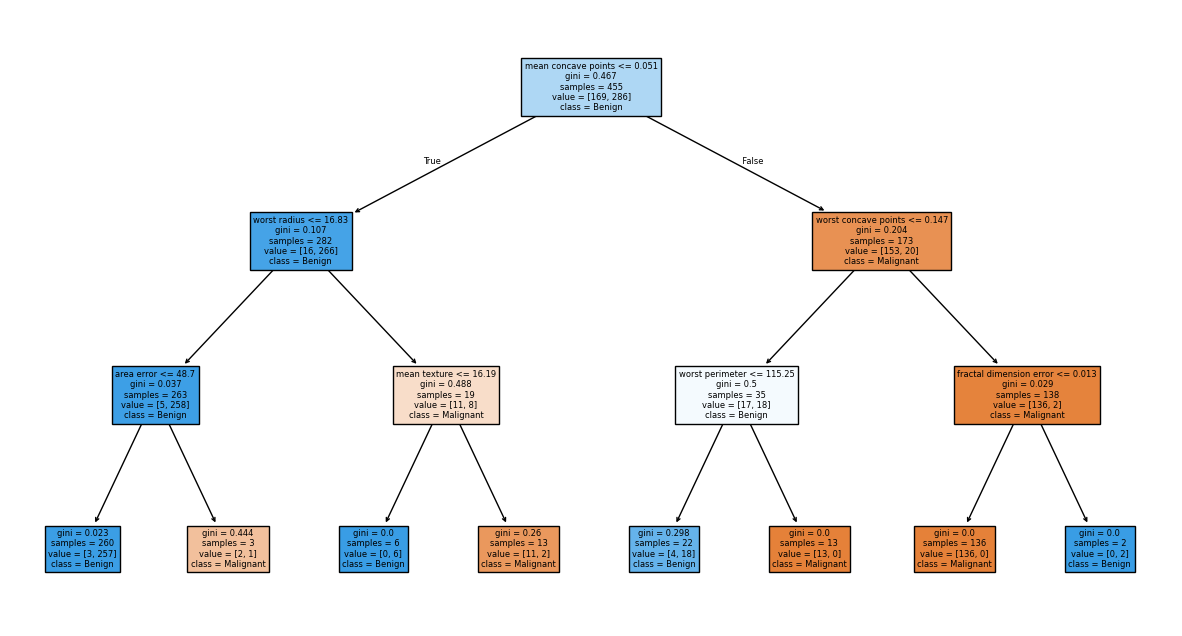

Random Forest Accuracy: 0.9649122807017544

Top 10 Important Features:
                 Feature  Importance
23            worst area    0.153892
27  worst concave points    0.144663
7    mean concave points    0.106210
20          worst radius    0.077987
6         mean concavity    0.068001
22       worst perimeter    0.067115
2         mean perimeter    0.053270
0            mean radius    0.048703
3              mean area    0.047555
26       worst concavity    0.031802


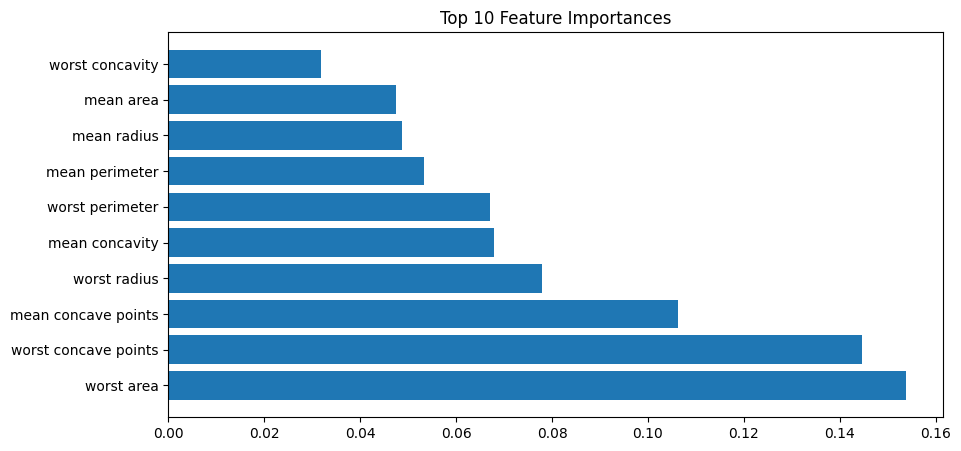


Cross Validation Scores: [0.92105263 0.93859649 0.98245614 0.96491228 0.97345133]
Average CV Score: 0.9560937742586555


In [2]:
# Task 5 - Decision Trees and Random Forests

# Import Libraries
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Load Dataset
data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Decision Tree
dt = DecisionTreeClassifier(max_depth=3, random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

dt_accuracy = accuracy_score(y_test, y_pred_dt)
print("Decision Tree Accuracy:", dt_accuracy)

# Visualize Tree
plt.figure(figsize=(15,8))
plot_tree(
    dt,
    feature_names=X.columns,
    class_names=['Malignant','Benign'],
    filled=True
)
plt.show()

# Random Forest
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

rf_accuracy = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", rf_accuracy)

# Feature Importance
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print("\nTop 10 Important Features:")
print(importance.head(10))

# Plot Feature Importance
plt.figure(figsize=(10,5))
plt.barh(
    importance['Feature'][:10],
    importance['Importance'][:10]
)
plt.title("Top 10 Feature Importances")
plt.show()

# Cross Validation
scores = cross_val_score(
    rf,
    X,
    y,
    cv=5
)

print("\nCross Validation Scores:", scores)
print("Average CV Score:", scores.mean())